In [1]:
%matplotlib widget
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools

import re
import os
import pickle
from cpymad.madx import Madx

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import TECA

import elements as el
import optimisers as op
import importlib

# Creating the knobs

In [2]:
importlib.reload(op)

# Creating the orthogonal knobs in LSS4
line = el.initialise_lineQ22()

Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4603 [00:00<?, ?it/s]

Non-channeled particle lost at element ap.up.mst21774_aper (index 1117) on turn 0
Adjusting ap.up.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21774_aper (index 1122) on turn 0
Adjusting ap.do.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21779_aper (index 1125) on turn 0
Adjusting ap.up.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21779_aper (index 1130) on turn 0
Adjusting ap.do.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21794_aper (index 1133) on turn 0
Adjusting ap.up.mst21794_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21794_a

In [3]:
bumpers = {
    "mpsh.41402": "kmpsh41402",
    "mplh.41658": "kmplh41658",
    "mplh.41994": "kmplh41994",
    "mpsh.42198": "kmpsh42198"
}

def plot_bump(ax, show_elements=True, **kwargs):
    tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d").to_pandas()
    tw.index = tw.name
    tw.plot(x='s', y='x', ax=ax, **kwargs)
    if show_elements:
        ax.axvline(tw.loc['TECA.entry'].s, color='k', linestyle='--')
        for name in ['mpsh.41402', 'mplh.41658', 'mplh.41994', 'mpsh.42198']:
            ax.axvline(tw.loc[name].s, color='r', linestyle='--', label=name)
            ax.text(tw.loc[name].s, tw.x.max()/2, name, rotation=90, verticalalignment='bottom', horizontalalignment='right', color='red')

        for name in tw.loc['mpsh.41402':'mpsh.42198'].name:
            if 'q' in name:
                ax.axvline(tw.loc[name].s, color='g', linestyle='--', label=name)
                ax.text(tw.loc[name].s, tw.x.max()/2, name, rotation=90, verticalalignment='bottom', horizontalalignment='right', color='green')

    ax.set_xlim(3800, 4200)

# Horizontal knob

                                             
Optimize - start penalty: 0.528                             
Matching: model call n. 25 penalty = 2.4758e-11              
Optimize - end penalty:  2.47576e-11                            


<Axes: >

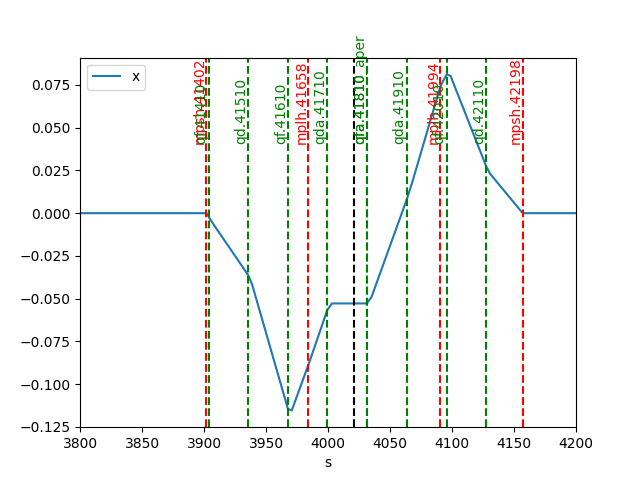

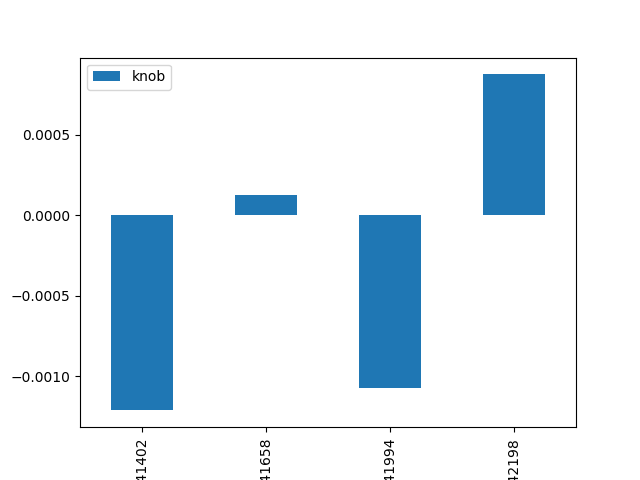

In [4]:
fig, ax = plt.subplots()


opt_x_LSS4 = op.normalized_x_knobLSS4(line)

plot_bump(ax)

settings = {}
for name, knob in bumpers.items():
    settings[name] = line.vv[knob]

settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')

In [5]:
from copy import copy
line.env["x_teca_knob"] =  0 # mm
for name, knob in bumpers.items():
    line.env[name + "_init_x"] = copy(line.vv[knob]) / ((TECA.jaw - TECA.width) * 1e3) # mm normalizing the knob to the TECA jaw width
    line.vv[knob] = name + "_init_x * x_teca_knob"

### Checking around small normalized values of the knob 

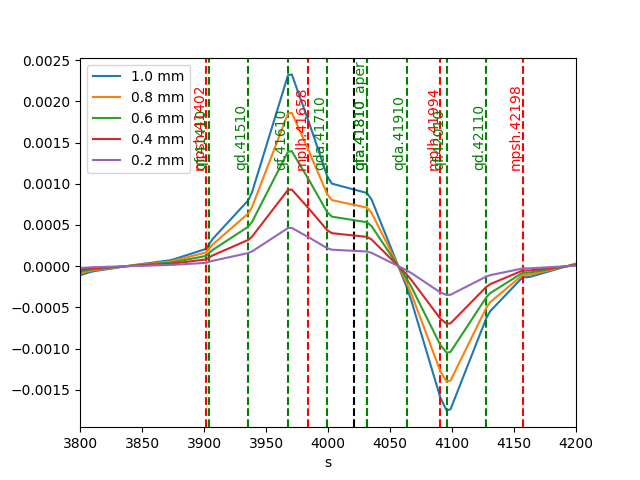

In [6]:
fig, ax = plt.subplots()
for i, knob in enumerate([0.2, 0.4, 0.6, 0.8, 1.0][::-1]):
    line.env["x_teca_knob"] = knob
    plot_bump(ax, show_elements=True if i == 0 else False, label=f"{knob:.1f} mm")

# Checking next to crystal values (after normalization)

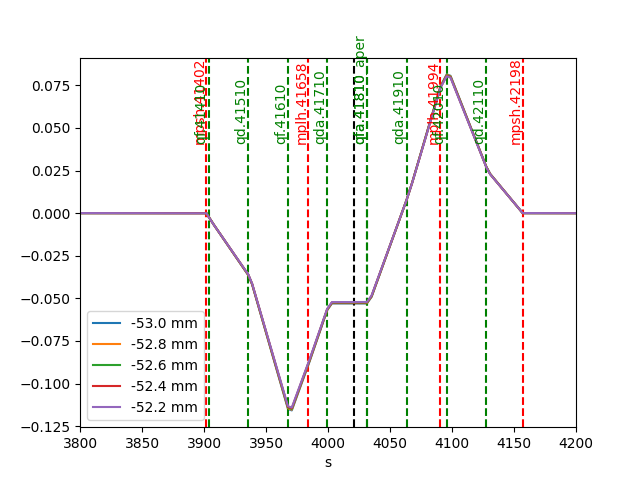

In [7]:
fig, ax = plt.subplots()
for i, knob in enumerate([TECA.jaw*1e3 - 0.2, TECA.jaw*1e3 - 0.4, TECA.jaw*1e3 - 0.6, TECA.jaw*1e3 - 0.8, TECA.jaw*1e3 - 1.0][::-1]):
    line.env["x_teca_knob"] = knob
    plot_bump(ax, show_elements=True if i == 0 else False, label=f"{knob:.1f} mm")

# Angle knob

                                             
Optimize - start penalty: 0.123                             
Matching: model call n. 26 penalty = 4.0473e-09              
Optimize - end penalty:  4.04729e-09                            


<Axes: >

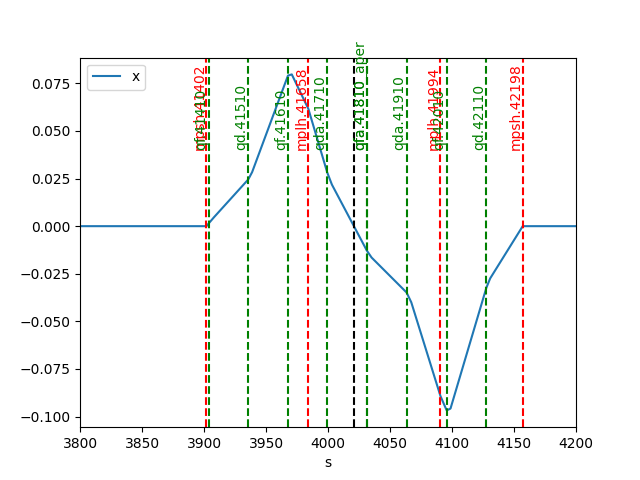

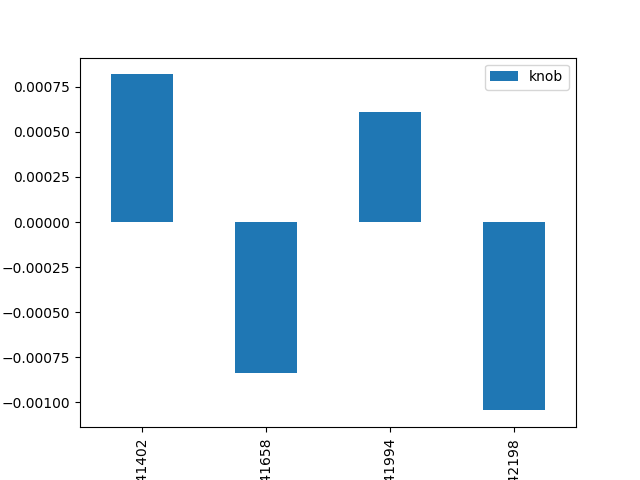

In [8]:
line.env["x_teca_knob"] =  0
opt_x_LSS4 = op.normalized_px_knobLSS4(line)

fig, ax = plt.subplots()
plot_bump(ax, show_elements=True)

settings = {}
for name, knob in bumpers.items():
    settings[name] = line.vv[knob]

settings = pd.DataFrame(settings, index=['knob']).T
settings.plot(kind='bar')

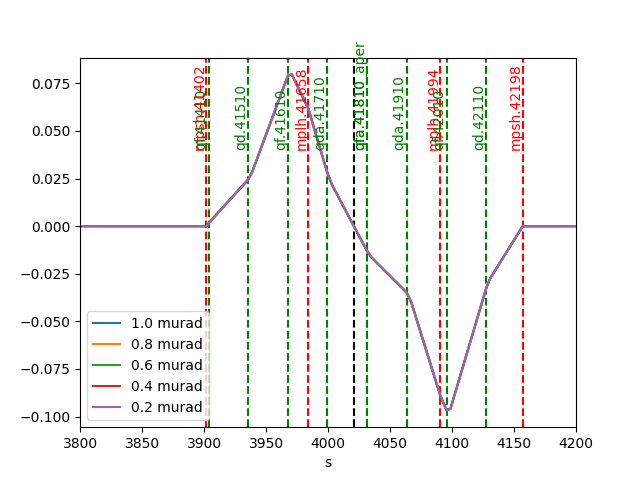

In [9]:
fig, ax = plt.subplots()
for i, knob in enumerate([0.2, 0.4, 0.6, 0.8, 1.0][::-1]):
    line.env["px_teca_knob"] = knob
    plot_bump(ax, show_elements=True if i == 0 else False, label=f"{knob:.1f} murad")

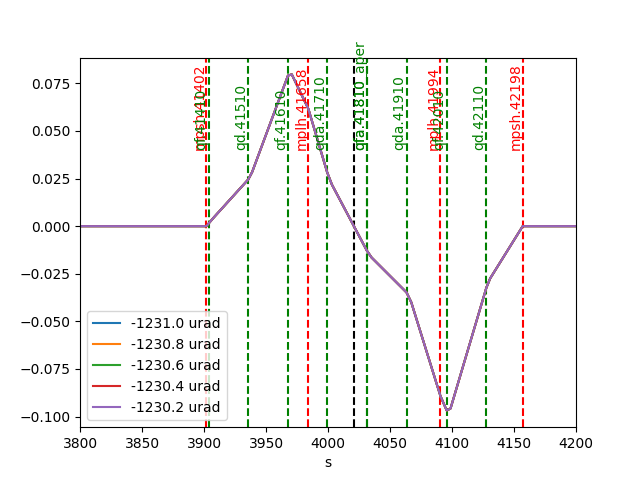

In [10]:
fig, ax = plt.subplots()
for i, knob in enumerate([TECA.tilt*1e6 - 0.2, TECA.tilt*1e6 - 0.4, TECA.tilt*1e6 - 0.6, TECA.tilt*1e6 - 0.8, TECA.tilt*1e6 - 1.0][::-1]):
    line.env["px_teca_knob"] = knob
    plot_bump(ax, show_elements=True if i == 0 else False, label=f"{knob:.1f} urad")

## Merging the two knobs

In [11]:
line.env["px_teca_knob"] =  0 # mm
for name, knob in bumpers.items():
    line.env[name + "_init_px"] = copy(line.vv[knob]) / (TECA.tilt * 1e6) # mm normalizing the knob to the TECA tilt
    line.vv[knob] = name + "_init_x * x_teca_knob + " + name + "_init_px * px_teca_knob "

## Checking expectation vs reality

In [12]:
x_knob_range = np.linspace(TECA.jaw*1e3 - TECA.width*1e3 - 3, TECA.jaw*1e3 - TECA.width*1e3 + 1, 10)
px_knob_range = np.linspace(TECA.tilt*1e6 - 20, TECA.tilt*1e6 + 20, 10)

results = {}


for i, x_knob in enumerate(x_knob_range):
    for j, px_knob in enumerate(px_knob_range):
        print(i, j, end='\r')
        line.env["x_teca_knob"] = x_knob * 1.25 # APPLYING A CORRECTION FACTOR
        line.env["px_teca_knob"] = px_knob * 1.55 # APPLYING A CORRECTION FACTOR
        tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d").to_pandas()
        tw.index = tw.name
        results[i*len(px_knob_range) + j] = {
            "x_mm": tw.loc['TECA.entry'].x * 1e3,  # Convert to mm
            "px_um": tw.loc['TECA.entry'].px * 1e6,  # Convert to um
            "x_knob": x_knob,
            "px_knob": px_knob
        }

results_df = pd.DataFrame.from_dict(results, orient='index')

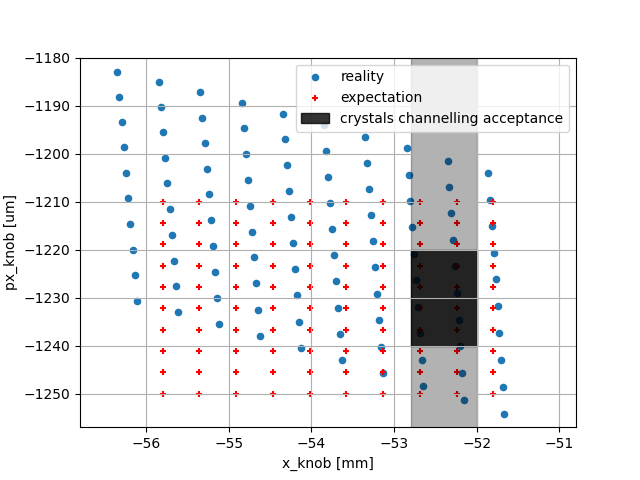

In [24]:
fig, ax = plt.subplots()
results_df.plot.scatter(x='x_mm', y='px_um', marker='o', ax=ax, label='reality')
results_df.plot.scatter(x='x_knob', y='px_knob', marker='+', ax=ax, color='red', label='expectation')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], [TECA.tilt*1e6 - 10]*2, [TECA.tilt*1e6 + 10]*2, color='k', alpha=0.8, label='crystals channelling acceptance')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], -10000, +1000, color='k', alpha=0.3)
ax.set_xlabel('x_knob [mm]')
ax.set_ylabel('px_knob [um]')
ax.set_xlim(TECA.jaw*1e3 - TECA.width*1e3 - 4, TECA.jaw*1e3 - TECA.width*1e3 + 2)
ax.set_ylim(TECA.tilt*1e6 - 27, TECA.tilt*1e6 + 50)
ax.legend()
ax.grid(True)
